In [2]:
#xesmf_env
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import xesmf as xe
import pandas as pd
import numpy as np

The conversion achieves these objectives:

> mHM grids needs to be aligned. The grids of the finer resolution dataset must fit into those of the coarser resolution dataset. Typically, the coarse grid must fit the finer grid by $2^n$ times. So the meteorological data must be resampled spatially to align the grids and achieve this fit. The alignment in this notebook is achieved by coarsening the finer grid and gridding the coarse data onto this grid.
>
> Secondly, the time dimension must be converted from the datetime format to CF conventions format. In this format, every time/date translates to one number. 
>
> When reading or writing netCDF files, xarray automatically decodes datetime and timedelta arrays using CF (Climate and Forecast) conventions (that is, by using a units attribute like 'days since 2000-01-01'). These formats ensure that datetime values are stored as integers or floats relative to a reference date, which are then decoded into human-readable dates upon loading.

I found these explanations why the CF format is desirable:
https://www.reddit.com/r/explainlikeimfive/comments/zxqogq/eli5_why_is_displayed_time_connected_with_unix/?rdt=56027

>> The whole reason Unix time was invented is that it's much easier for a computer to track a single, very large number that increases steadily, forever, than the human system of small numbers of seconds adding up to minutes and hours and days and so on.
>>Storage Efficiency: int32 uses less memory than datetime or float64 types, which can be significant for large datasets.

### Import data
Import mHM morphology data, the dataset to be gridded


In [5]:
mHM_grid = xr.open_dataset(r"W:\VUB\_main_research\mHM\mhm_belgium\belgium\lai\lai.nc", decode_times=False)
#rmi_data = xr.open_dataset(r'W:\VUB\_main_research\data\RMI\RMI_mHM_data.nc')

#mHM Eobs observation data
pre = xr.open_dataset(r"W:\VUB\_main_research\mHM\mhm_belgium\belgium\meteo_era5\meteo_1950_2023\pre.nc", decode_times=False)

In [6]:
pre

<xarray.Dataset> Size: 31MB
Dimensions:    (time: 27028, bnds: 2, lon: 20, lat: 14)
Coordinates:
  * time       (time) int32 108kB 438311 438335 438359 ... 1086935 1086959
  * lon        (lon) float64 160B 2.125 2.375 2.625 2.875 ... 6.375 6.625 6.875
  * lat        (lat) float64 112B 51.88 51.62 51.38 51.12 ... 49.12 48.88 48.62
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) float64 432kB ...
    pre        (time, lat, lon) float32 30MB ...
Attributes:
    CDI:          Climate Data Interface version 2.2.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    frequency:    day
    NCO:          netCDF Operators version 4.9.7 (Homepage = http://nco.sf.ne...
    history:      Wed Sep 25 09:31:44 2024: cdo -f nc4c -z zip_4 mergetime pr...
    CDO:          Climate Data Operators version 2.2.2 (https://mpimet.mpg.de...

In [ ]:
xr.decode_cf(pre)

####  Regrid and Clip Meteorological and LAI data

In [68]:
#Define bounding region. This region defines the domain of the model
lat_max =  mHM_grid.lat.min() + 3
lat_min =  mHM_grid.lat.min() + 1
lon_max =  mHM_grid.lon.min() + 4.5
lon_min =  mHM_grid.lon.min() + 0.5

In [29]:
# Define latitudes and longitudes for the target grid with consistent steps
# Adjust to match the coarser grid resolution if necessary
"""Upon further inspection, the grid values are lat and lon centres so to match the xllcorner and yllcorner values,
we need to adjust the grid values to match the corners. This is done by adding half of the grid resolution to the min values
"""

grid_lats = np.arange(lat_min, lat_max, 0.03125)  # Include + step size
grid_lons = np.arange(lon_min, lon_max, 0.03125)

# Create the target grid
ds_meteo_target = xr.Dataset(
    coords={
        "lat": (["lat"], grid_lats),
        "lon": (["lon"], grid_lons),
    }
)

# Adjust LAI target grid similarly, ensuring consistent shape
lai_grid_lats = np.arange(lat_min, lat_max, 0.001953125)
lai_grid_lons = np.arange(lon_min, lon_max, 0.001953125)

lai_target_grid = xr.Dataset(
    coords={
        "lat": (["lat"], lai_grid_lats),
        "lon": (["lon"], lai_grid_lons),
    }
)

# 4. Regrid the meteo data (e.g., rmi_data) to the target grid (same as LAI target grid)
regridder_meteo = xe.Regridder(rmi_data, ds_meteo_target, method='bilinear')
ds_met_grid = regridder_meteo(rmi_data)  # Regrid meteo data to target grid

# 3. Regrid the LAI data to the target grid of meteo (coarser resolution)
regridder_lai = xe.Regridder(mHM_grid, lai_target_grid, method='bilinear')
lai_gridded = regridder_lai(mHM_grid)  # Regrid LAI data to target grid

#### Clip mHM LAI and meteorological inputs to the extent

In [47]:
#Determine the bounding box of the original met dataset
lat_min = float(rmi_data.lat.min())
lat_max = float(rmi_data.lat.max())
lon_min = float(rmi_data.lon.min())
lon_max = float(rmi_data.lon.max())

#Mask out (set to NaN) any cells outside the original lat/lon extents
#This is necessary because the xesmf interpolation will fill the extra cells with zeros
# Now ds_met_grid will have NaN outside the original rmi_data boundaries
ds_met_region = ds_met_grid.where(
    (ds_met_grid.lat >= lat_min)
    & (ds_met_grid.lat <= lat_max)
    & (ds_met_grid.lon >= lon_min)
    & (ds_met_grid.lon <= lon_max)
)

# lai_region = lai_gridded.where(
#     (lai_gridded.lat >= lat_min)
#     & (lai_gridded.lat <= lat_max)
#     & (lai_gridded.lon >= lon_min)
#     & (lai_gridded.lon <= lon_max)
# )

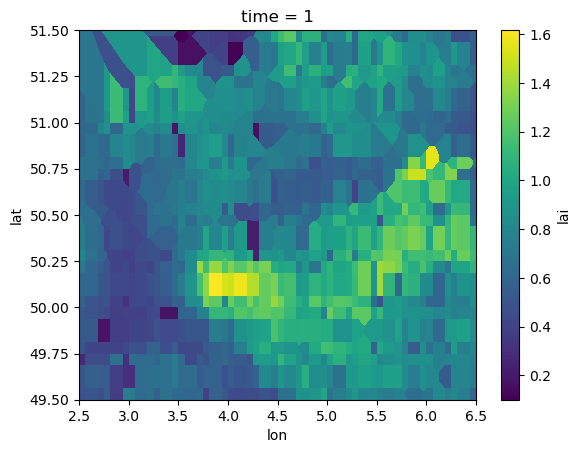

In [88]:
lai_gridded['lai'].isel(time=0).plot()

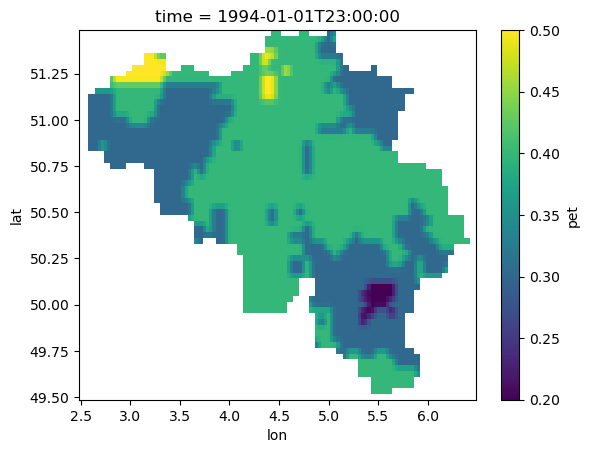

In [52]:
#Plot results
ds_met_region['pet'].isel(time=0).plot()

### Assign mHM-like attributes

### Convert date to CF format
One limitation of using datetime64[ns] is that it limits the native representation of dates to those that fall between the years 1678 and 2262. 

mHM datetime is provided according to CF conventions with units 'timestep since YYYY-MM-DD' where timestep could be hours, days, months ...
https://docs.xarray.dev/en/latest/user-guide/time-series.html


The date is decoded through
xr.decode_cf(ds) where ds is an xr.Dataset

In [90]:
#assign units to lat and lon and time
lai_gridded['lai'].attrs = mHM_grid['lai'].attrs
lai_gridded['lat'].attrs = mHM_grid['lat'].attrs
lai_gridded['lon'].attrs = mHM_grid['lon'].attrs
lai_gridded['time'].attrs = mHM_grid['time'].attrs
lai_gridded['time'].attrs['units'] = 'months since 1982-01-01'

In [54]:
# Define the reference date
reference_date = rmi_data.time[0].values

# Convert 'datetime' to the number of days since the reference date
ds_met_region['time'] = (rmi_data['time'] - reference_date).dt.days.astype('int32')

#assign attributes to time
ds_met_region.time.attrs['units'] = 'days since ' + str(reference_date)
ds_met_region.time.attrs['calendar'] = 'gregorian'
ds_met_region.time.attrs['standard_name'] = 'time'
ds_met_region.time.attrs['long_name'] = 'time'

In [55]:
#ds_met_region = ds_met_region.fillna(-9999)
ds_met_region['lat'].attrs['units'] = 'degrees_north'
ds_met_region['lon'].attrs['units'] = 'degrees_east'
ds_met_region['pre'].attrs['units'] = 'mm'
ds_met_region['pre'].attrs['long_name'] = 'Total Precipitation'
ds_met_region['pet'].attrs['units'] = 'mm'
ds_met_region['pet'].attrs['long_name'] = 'Potential Evapotranspiration'
ds_met_region['tavg'].attrs['units'] = 'degrees C'
ds_met_region['tavg'].attrs['long_name'] = 'Average Temperature'

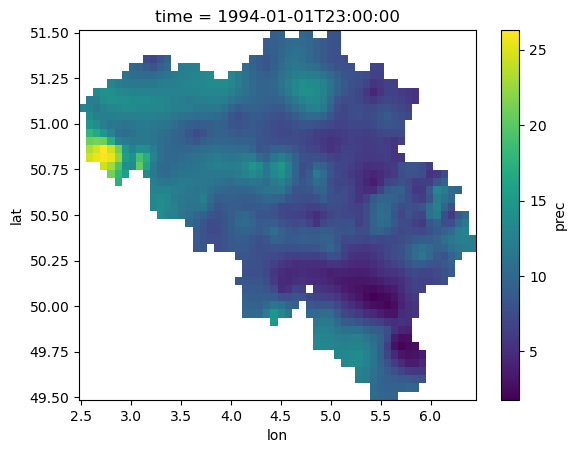

In [125]:
rmi_data['prec'].isel(time=0).plot()

#### Sort lat lon

In [ ]:
# Reverse the latitude axis
lai_gridded = lai_gridded.sel(lat=sorted(lai_gridded.lat, reverse=True))
ds_met_region = ds_met_region.sel(lat=sorted(ds_met_region.lat, reverse=True))

In [118]:
#for ds_met_region, replace nan values with -9999
for var in vars:
    ds_met_region[var] = ds_met_region[var].fillna(-9999)

#### Export to NetCDF

In [119]:
vars = ['pet', 'pre', 'tavg']

for var in vars:
    ds_met_region[var].to_netcdf(r'W:\VUB\_main_research\mHM\mhm_belgium\RMI\meteo\{}\{}.nc'.format(var,var))

#lai_gridded.to_netcdf(r'W:\VUB\_main_research\mHM\mhm_belgium\RMI\lai\lai.nc')


In [61]:
""""
Finish processing the files with terminal commands

"""

'"\nFinish processing the files with terminal commands\n\n'